In [31]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [32]:
sub_merged = pd.read_excel("../../data/processed/team/subway_merged_base.xlsx")
sub_merged['TOTAL_W'] = sub_merged['ES'] + sub_merged['EV']*4
sub_merged.drop(columns=['총승차인원', '무임승차인원', '총하차인원', '무임하차인원'], inplace=True)

In [33]:
# 시설부하지수 상위 20% 역
priorities = pd.read_csv("../../data/processed/team/priority_area.csv", encoding='cp949')
priorities.drop(columns=['총승차인원', '무임승차인원', '총하차인원', '무임하차인원'], inplace=True)
priorities.head()

,지하철역,호선명,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,종로5가,1,1410815,488319,34.61,3,0,3,40693.25
1,청량리,1,1319724,561989,42.58,2,6,8,40142.07
2,제기동,1,1013099,559716,55.25,3,2,5,39979.71
3,미아사거리,4,1544727,380795,24.65,2,2,4,38079.50
4,상계,4,1096973,261592,23.85,1,4,5,32699.00


In [34]:
transfer = pd.read_excel("../../data/processed/team/transfer_merged_final.xlsx")
transfer_master = pd.merge(sub_merged, transfer[['지하철역', '호선', '환승노선', '환승거리', '환승소요시간']], on='지하철역', how='left')
transfer_master = transfer_master.sort_values(by='환승거리', ascending=False)
transfer_master.loc[transfer_master['지하철역']=='서울역', '지하철역'] = '서울'
transfer_master = transfer_master[~(transfer_master['지하철역']=='지축')]

In [35]:
lines_sep_merged = pd.read_excel("../../data/processed/team/lines_sep_merged.xlsx")

In [36]:
lines_sep_merged[['ES', 'EV', 'TOTAL_W']] = lines_sep_merged[['ES', 'EV', 'TOTAL_W']].astype('Int64')
lines_sep_merged['시설부하지수'] = (lines_sep_merged['무임승하차'] / lines_sep_merged['TOTAL_W']).round(2)

In [37]:
drop_station = ['뚝섬유원지', '당고개', '신내']
lines_sep_merged = lines_sep_merged[~lines_sep_merged['지하철역'].isin(drop_station)]
lines_sep_merged.loc[lines_sep_merged['지하철역']=='서울역', '지하철역'] = '서울'
# 1. 호선명이 '서울'로 잘못 들어간 곳을 다시 '1호선'으로 수정
lines_sep_merged.loc[lines_sep_merged['호선명'] == '서울', '호선명'] = '1호선'

In [38]:
lines_sep_merged_core=lines_sep_merged[lines_sep_merged['지하철역'].isin(priorities['지하철역'])]
lines_sep_merged_core['지하철역'].unique()
lines_sep_merged_core

,호선명,지하철역,전체승하차,무임승하차,무임승하차비중,노선분류,ES,EV,TOTAL_W,시설부하지수
0,1호선,동대문,718764,249909,34.77,old,1,3,13,19223.77
2,1호선,서울,3483172,445341,12.79,old,5,4,21,21206.71
5,1호선,제기동,1011362,558794,55.25,old,2,3,14,39913.86
6,1호선,종각,2191168,291778,13.32,old,2,4,18,16209.89
7,1호선,종로3가,1481992,564539,38.09,old,4,3,16,35283.69
8,1호선,종로5가,1407939,487010,34.59,old,0,3,12,40584.17
9,1호선,청량리,1317194,561250,42.61,old,6,2,14,40089.29
10,2호선,강남,4541560,301448,6.64,old,0,4,16,18840.5
11,2호선,강변,1724930,234284,13.58,old,2,2,10,23428.4
13,2호선,교대,1890674,328795,17.39,old,4,3,16,20549.69


In [42]:
# 호선명을 문자열로 통일 (int 타입이어도 매핑이 동작하도록)
LINE_COLOR_MAP = {
    '1': '#0052A4', '2': '#00A84D', '3': '#EF7C1C', '4': '#00A5DE',
    '5': '#996CAC', '6': '#CD7C2F', '7': '#747F00', '8': '#E6186C', '9': '#BDB092',
}

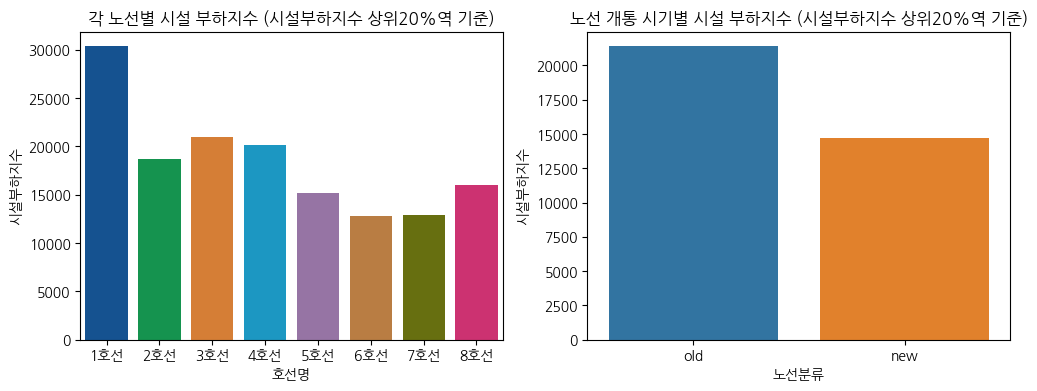

In [45]:
palette_map = {f"{k}호선": v for k, v in LINE_COLOR_MAP.items()}

fig, axes = plt.subplots(1, 2, figsize= (12, 4))

sns.barplot(
    data=lines_sep_merged_core,
    x='호선명',
    y='시설부하지수',
    errorbar=None,
    ax=axes[0],
    palette=palette_map,
    hue='호선명',         
    legend=False
)

sns.barplot(
    data=lines_sep_merged_core,
    x='노선분류',
    y='시설부하지수',
    hue='노선분류',
    errorbar=None,
    ax=axes[1]
)

axes[0].set_title("각 노선별 시설 부하지수 (시설부하지수 상위20%역 기준)")
axes[1].set_title("노선 개통 시기별 시설 부하지수 (시설부하지수 상위20%역 기준)")

plt.show()